In [1]:
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df = pd.read_csv('winequality-red.csv')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


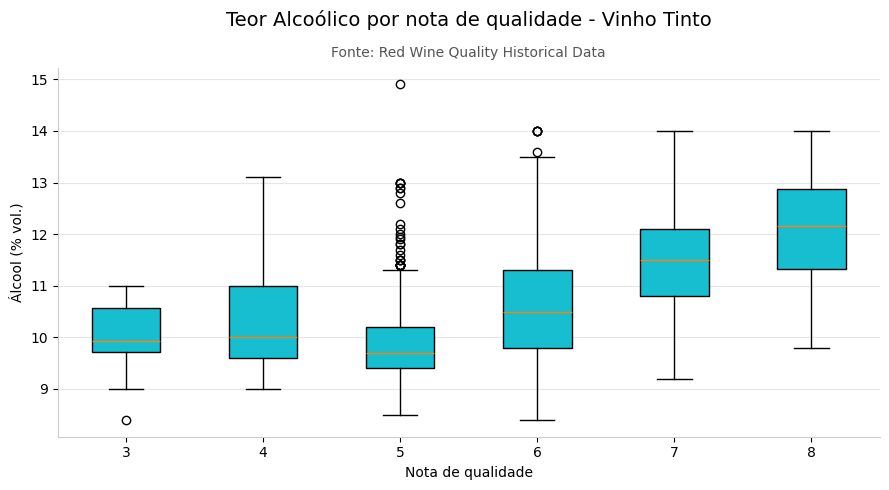

In [11]:
# Cria grupos de dados de teor alcoólico separados pela qualidade do vinho
# Isso é necessário para o boxplot, pois ele precisa de uma lista de arrays/series
# onde cada elemento representa um grupo diferente

# sorted(df['quality'].unique()) -> [3, 4, 5, 6, 7, 8] (qualidades únicas ordenadas)
# Para cada qualidade q:
#   df[df['quality'] == q]['alcohol'] -> filtra vinhos com qualidade q e pega apenas a coluna alcohol
# Resultado: lista de 6 Series, uma para cada qualidade (3, 4, 5, 6, 7, 8)

groups = [df[df['quality'] == q]['alcohol'] for q in sorted(df['quality'].unique())]

fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot(groups, tick_labels=sorted(df['quality'].unique()), patch_artist=True,
            boxprops=dict(facecolor='#17becf'))

ax.set_title('Teor Alcoólico por nota de qualidade - Vinho Tinto', fontsize=14, pad=30)
ax.text(
    0.5,
    1.02,
    "Fonte: Red Wine Quality Historical Data",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=10,
    color="#555555",
)

ax.set_xlabel('Nota de qualidade')
ax.set_ylabel('Álcool (% vol.)')

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

for spine in ["left", "bottom"]:
    ax.spines[spine].set_color("#cccccc")

ax.grid(axis="y", color="#e6e6e6", linewidth=0.8)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("box_plot_wine.png", dpi=1000)
plt.show()